dont expect anything but the very last cell in this notebook to work. I make breaking changes constantly and do not bother to go back and fix them

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from shared.sampling import random_latin_hypercube, space_filling_latin_hypercube, find_subset, align_subset
from shared.sample_funcs import peaks, appendix_one, branin
from shared.psi import psi
from shared.surrogates.kriging import Kriging
from shared.surrogates.rbf import RBF

# 2 Constructing a Surrogate

## 2.3 Radial Basis Function Models

$$f(x) = \bm{w}^T \bm{\psi} = \sum_{i=1}^{n_c}w_i\psi(\left\lVert x-c^{(i)} \right\rVert)$$

In [ ]:
# 1D APPENDIX EXAMPLE
X_sample   = np.linspace(0,1,25).reshape(-1,1)
Y_sample   = appendix_one(X_sample)

D_sample   = cdist(X_sample, X_sample)
PSI_sample = psi(D_sample, code = 3)

W = np.linalg.solve(PSI_sample, Y_sample)

X   = np.linspace(0,1,100).reshape(-1,1)
D   = cdist(X, X_sample)
PSI = psi(D, code = 3)

func_latex = r'$f(x) = (6x - 2)^2 \sin(12x - 4)$'

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 5))

# --- RBF approximation ---
y = PSI @ W
ax1.plot(X, y)
ax1.set_title('Radial Basis Function Approximation')
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$\hat{f}(x)$')

# --- Actual function ---
y = appendix_one(X)
ax2.plot(X, y)
ax2.set_title('Actual Function')
ax2.set_xlabel(r'$x$')

fig.suptitle(func_latex, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
func_latex = (r'$f(x,y) = 3(1-x)^2 e^{-x^2-(y+1)^2} '
              r'- 10\left(\frac{x}{5} - x^3 - y^5\right) e^{-x^2-y^2} '
              r'- \frac{1}{3} e^{-(x+1)^2-y^2}$')

# --- Evaluate both surfaces on a grid ---
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
matr = np.hstack((X.reshape((-1, 1)), Y.reshape((-1, 1))))

Z_true = peaks(matr).reshape((200,200))

# --- Plot side by side ---
sample_sizes = [5,10,25,50,100]
n_plots = len(sample_sizes) + 1 

fig = plt.figure(figsize=(8, 6*n_plots))

ax = fig.add_subplot(n_plots, 1, 1, projection='3d')
surf2 = ax.plot_surface(X, Y, Z_true, cmap='viridis', linewidth=0, antialiased=True)
ax.set_title('Actual Function')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$f(x,y)$')
fig.colorbar(surf2, ax=ax, shrink=0.5, aspect=10)

for i, size in enumerate(sample_sizes):

    # --- Fit the RBF surrogate ---
    X_rlhc     = random_latin_hypercube(size, 2, [-3]*2, [3]*2)
    X_sample,_ = space_filling_latin_hypercube(X_rlhc)
    D_sample   = cdist(X_sample, X_sample)
    PSI_sample = psi(D_sample, code = 3)
    Z_sample   = peaks(X_sample)
    W = np.linalg.solve(PSI_sample, Z_sample)

    D    = cdist(matr, X_sample)
    PSI  = psi(D, code = 3)
    Z_rbf  = (PSI @ W).reshape((200, 200))

    ax2 = fig.add_subplot(n_plots, 1, i+2, projection='3d')
    surf1 = ax2.plot_surface(X, Y, Z_rbf, cmap='viridis', linewidth=0, antialiased=True)
    ax2.set_title(f'Radial Basis Function Approximation; sample_count: {size}')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$y$')
    ax2.set_zlabel(r'$\hat{f}(x,y)$')
    fig.colorbar(surf1, ax=ax2, shrink=0.5, aspect=10)

fig.suptitle(func_latex, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
x = np.linspace(-3,3,100)
y = np.logspace(-3,3,100)

plt.plot(x, y)

plt.show()

In [ ]:
func_latex = (r'$f(x,y) = 3(1-x)^2 e^{-x^2-(y+1)^2} '
              r'- 10\left(\frac{x}{5} - x^3 - y^5\right) e^{-x^2-y^2} '
              r'- \frac{1}{3} e^{-(x+1)^2-y^2}$')

# --- Evaluate both surfaces on a grid ---
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
matr = np.hstack((X.reshape((-1, 1)), Y.reshape((-1, 1))))

Z_true = peaks(matr).reshape((200,200))

# --- Plot side by side ---
sample_sizes = [5,10,25,50,100]
n_plots = len(sample_sizes) + 1 

fig = plt.figure(figsize=(8, 6*n_plots), dpi=100)

ax = fig.add_subplot(n_plots, 1, 1, projection='3d')
surf2 = ax.plot_surface(X, Y, Z_true, cmap='viridis', linewidth=0, antialiased=True)
ax.set_title('Actual Function')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$f(x,y)$')
fig.colorbar(surf2, ax=ax, shrink=0.5, aspect=10)

code = 6
for i, size in enumerate(sample_sizes):

    # --- Fit the RBF surrogate ---
    k = 2
    X_rlhc = random_latin_hypercube(size, k, [-3]*k, [3]*k)
    X_sample, _ = space_filling_latin_hypercube(X_rlhc)

    rbf = RBF(X_sample, peaks, code=code)
    sigma      = rbf.sigma
    PSI_sample = rbf.get_psi_matrix(X_sample, X_sample, sigma)
    Z_sample   = peaks(X_sample)
    W          = np.linalg.solve(PSI_sample, Z_sample)

    D    = cdist(matr, X_sample)
    PSI  = psi(D, code, sigma)
    Z_rbf  = (PSI @ W).reshape((200, 200))

    ax2 = fig.add_subplot(n_plots, 1, i+2, projection='3d')
    surf1 = ax2.plot_surface(X, Y, Z_rbf, cmap='viridis', linewidth=0, antialiased=True)
    ax2.set_title(f'Radial Basis Function Approximation; basis function: multi-quadratic; size: {size}')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$y$')
    ax2.set_zlabel(r'$\hat{f}(x,y)$')
    fig.colorbar(surf1, ax=ax2, shrink=0.5, aspect=10)

fig.suptitle(func_latex, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
Nside = 200
x = np.linspace(-5, 10, Nside)
y = np.linspace(0, 15, Nside)
X, Y = np.meshgrid(x, y)
matr = np.hstack((X.reshape((-1, 1)), Y.reshape((-1, 1))))
Z_true = branin(matr).reshape((Nside, Nside))

k = 2
n = 50

X_rlhc = random_latin_hypercube(n, k, [-5, 0], [10, 15])
X_sample = space_filling_latin_hypercube(X_rlhc)
kriging = Kriging(X_sample["X"], branin)

Z = np.ones([Nside * Nside])
for i in range(matr.shape[0]):
    Z[i] = kriging.evaluate(matr[i, :])
Z = Z.reshape((Nside, Nside))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

from matplotlib.colors import Normalize

vmin, vmax = Z_true.min(), Z_true.max()
levels = np.linspace(vmin, vmax, 21)
norm = Normalize(vmin=vmin, vmax=vmax)
# --- actual function ---
func_latex = (    
    r'$f(x,y) = \left(y - \frac{5.1}{4\pi^2}x^2 '
    r'+ \frac{5}{\pi}x - 6\right)^2 '
    r'+ 10\left(1 - \frac{1}{8\pi}\right)\cos(x) + 10$'
)
fill1 = ax1.contourf(X, Y, Z_true, levels=levels, norm=norm, cmap='Greys')
ax1.contour(X, Y, Z_true, levels=levels, colors='black', linewidths=0.8)
ax1.set_title(func_latex)
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')
ax1.set_aspect('equal')
fig.colorbar(fill1, ax=ax1, shrink=0.5, aspect=10)

# --- kriging surrogate ---
fill2 = ax2.contourf(X, Y, Z, levels=levels, norm=norm, cmap='Greys')
ax2.contour(X, Y, Z, levels=levels, colors='black', linewidths=0.8)
ax2.scatter(kriging.X_sample[:, 0], kriging.X_sample[:, 1],
            color='black', marker='^', s=7.5)
ax2.set_title(rf'$\hat{{f}}(x,y)$ ($n={len(kriging.X_sample)}$)')
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$y$')
ax2.set_aspect('equal')
fig.colorbar(fill2, ax=ax2, shrink=0.5, aspect=10)

In [ ]:
func_latex = (r'$f(x,y) = 3(1-x)^2 e^{-x^2-(y+1)^2} '
              r'- 10\left(\frac{x}{5} - x^3 - y^5\right) e^{-x^2-y^2} '
              r'- \frac{1}{3} e^{-(x+1)^2-y^2}$')

Nside = 200
# --- Evaluate both surfaces on a grid ---
x = np.linspace(-3, 3, Nside)
y = np.linspace(-3, 3, Nside)
X, Y = np.meshgrid(x, y)
matr = np.hstack((X.reshape((-1, 1)), Y.reshape((-1, 1))))

Z_true = peaks(matr).reshape((Nside,Nside))

# --- Plot side by side ---
sample_sizes = [5,10,25,50,100]
n_plots = len(sample_sizes) + 1 

fig = plt.figure(figsize=(8, 6*n_plots))

ax = fig.add_subplot(n_plots, 1, 1, projection='3d')
surf2 = ax.plot_surface(X, Y, Z_true, cmap='viridis', linewidth=0, antialiased=True)
ax.set_title('Actual Function')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$f(x,y)$')
fig.colorbar(surf2, ax=ax, shrink=0.5, aspect=10)

for i, size in enumerate(sample_sizes):

    # --- Fit the RBF surrogate ---
    X_rlhc = random_latin_hypercube(size, 2, [-3]*2, [3]*2)
    X_sample = space_filling_latin_hypercube(X_rlhc)
    
    kriging = Kriging(X_sample["X"], peaks)
    Z_krig = np.ones([Nside*Nside])

    for j in range(matr.shape[0]):
        Z_krig[j] = kriging.evaluate(matr[j,:])
        
    Z_krig = Z_krig.reshape((Nside, Nside))

    ax2 = fig.add_subplot(n_plots, 1, i+2, projection='3d')
    surf1 = ax2.plot_surface(X, Y, Z_krig, cmap='viridis', linewidth=0, antialiased=True)
    ax2.set_title(f'Kriging Approximation; size: {size}')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$y$')
    ax2.set_zlabel(r'$\hat{f}(x,y)$')
    fig.colorbar(surf1, ax=ax2, shrink=0.5, aspect=10)

fig.suptitle(func_latex, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
n = 100
k = 2
rlhc = random_latin_hypercube(n,k)

X_c, q   = space_filling_latin_hypercube(rlhc)
X_e, phi = find_subset(X_c, 50, q)

aligned = align_subset(X_c, X_e)

In [ ]:
import numpy as np

from shared.cpcrr.methods import KrigingFitter

from shared.cpcrr.functions import onevar


datax = np.array([
    0.0,
    0.24,
    0.5,
    0.65,
    # 0.82,
    # 0.9,
    1.0,
])
datay = onevar(datax)

KF = KrigingFitter(
    xmin=(0,),
    xmax=(1,),
    datax=datax,
    datay=datay,
)

# KF.plot_check_inputs(objective=onevar)

KF.fit(
    # verbose=True,
)

print("Done.")
print(f"µ {KF.globmean} σ2 {KF.globvar}")
print(f"θ {KF.theta}")
print(f"result {KF.result}")

KF.plot_check_model(res=100, objective=onevar)

KF.test_check_model()

Done.
µ -3.445195152542812 σ2 27.20176787461706
θ [16.82617814]
result   message: ABNORMAL: 
  success: False
   status: 2
      fun: -7.878043758417174
        x: [ 1.683e+01]
      nit: 7
      jac: [-5.551e+02]
     nfev: 184
     njev: 92
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>


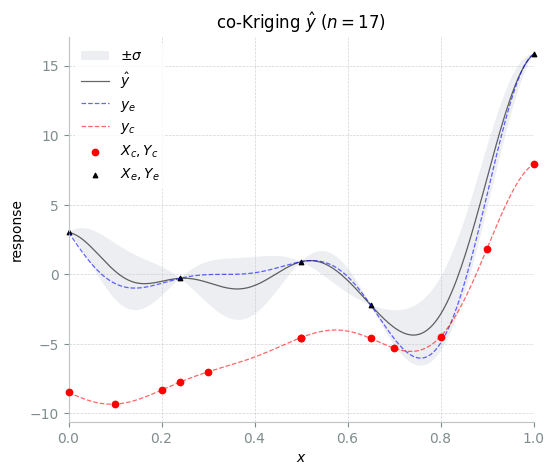

In [2]:
import numpy as np

from shared.cpcrr.methods.cokrigingfitter import CoKrigingFitter
from shared.cpcrr.functions import onevar, onevarAD

x_c = np.array([
    0,
    0.24,
    0.5,
    0.65,
    1.0,
    0.1,
    0.2,
    0.3,
    0.5,
    0.7,
    0.8,
    0.9
])
y_c = onevarAD(x_c)
nlow = x_c.shape[0]

x_e = datax = np.array([
    0.0,
    0.24,
    0.5,
    0.65,
    # 0.82,
    # 0.9,
    1.0,
])
y_e = onevar(x_e)

datax = np.concatenate([x_c, x_e])
datay = np.concatenate([y_c, y_e])

if len(datax.shape) == 1:
    datax = datax.reshape(-1,1)


CKF = CoKrigingFitter(
    xmin=(0,),
    xmax=(1,),
    datax=datax,
    datay=datay,
    nlow=nlow
)


# CKF.plot_check_inputs(objective=onevar)


CKF.fit(
    # verbose=True,
)


print("Done.")
print(f"µ {CKF.globmean} σ2 {CKF.globvar}")
print(f"θ {CKF.theta}")
print(f"result {CKF.result}")

CKF.plot_check_model(objective_e=onevar, objective_c=onevarAD,res=200)